In [152]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from collections import Counter


In [153]:
from sklearn.model_selection import train_test_split

In [154]:
df=pd.read_csv("Combined Data.CSV")
df.tail()


,Unnamed: 0,statement,status
53038,53038,Nobody takes me seriously I’ve (24M) dealt wit...,Anxiety
53039,53039,"selfishness ""I don't feel very good, it's lik...",Anxiety
53040,53040,Is there any way to sleep better? I can't slee...,Anxiety
53041,53041,"Public speaking tips? Hi, all. I have to give ...",Anxiety
53042,53042,I have really bad door anxiety! It's not about...,Anxiety


In [155]:
risk_map={
    "Anxiety": "High Risk",
    "Stress": "High Risk",
    "Depression": "High Risk",
    "Normal": "Stable",
    "Okay": "Stable",
    "Fine": "Stable",
    "Good": "Low Risk",
    "Happy": "Low Risk",
    "Calm": "Low Risk",
    "Excited": "Low Risk",
}

In [156]:
df.head()

,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


In [157]:
df["risk_level"]=df["status"].map(risk_map).fillna("Stable")

In [158]:
df.head()

,Unnamed: 0,statement,status,risk_level
0,0,oh my gosh,Anxiety,High Risk
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety,High Risk
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,High Risk
3,3,I've shifted my focus to something else but I'...,Anxiety,High Risk
4,4,"I'm restless and restless, it's been a month n...",Anxiety,High Risk


In [159]:
print("class Distribution:",Counter(df["risk_level"]))

class Distribution: Counter({'Stable': 31082, 'High Risk': 21961})


In [160]:
X_train,X_test,y_train,y_test=train_test_split(
    df["statement"], df["risk_level"], test_size=0.2, random_state=42,stratify=df["risk_level"])
print("Training set size:",X_train.shape)
print("Training test size:",X_test.shape)


Training set size: (42434,)
Training test size: (10609,)


In [161]:
df = df.dropna(subset=["statement"])


In [162]:
df.head()

,Unnamed: 0,statement,status,risk_level
0,0,oh my gosh,Anxiety,High Risk
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety,High Risk
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,High Risk
3,3,I've shifted my focus to something else but I'...,Anxiety,High Risk
4,4,"I'm restless and restless, it's been a month n...",Anxiety,High Risk


In [163]:
print(df[df["statement"].isnull()])

Empty DataFrame
Columns: [Unnamed: 0, statement, status, risk_level]
Index: []


In [164]:
print(X_train.apply(type).value_counts())


statement
<class 'str'>      42144
<class 'float'>      290
Name: count, dtype: int64


In [165]:
X_train

25446    Here i am , studying uni st my house, wif a ma...
40596    allt jag tweetar om r jobbet bus 9 och depress...
22038    Do you ever feel like you have no one to share...
12305    Several months ago I went through a terrible b...
7          Have you ever felt nervous but didn't know why?
                               ...                        
12332    it is all I ever do. My dreams are the only pl...
26132    Just going to throw this out into the ether. I...
32630                      i hope we'll catch a foul ball.
7566     24m have been thinking about offing myself for...
2256     The definition of waiting for a month's payche...
Name: statement, Length: 42434, dtype: object

In [166]:
y_train

25446       Stable
40596    High Risk
22038    High Risk
12305       Stable
7        High Risk
           ...    
12332       Stable
26132    High Risk
32630       Stable
7566        Stable
2256        Stable
Name: risk_level, Length: 42434, dtype: object

In [167]:
# Convert all values in statement column to string
X_train = X_train.astype(str)
X_test = X_test.astype(str)


In [168]:
vectorizer = TfidfVectorizer(max_features=2000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [169]:
model=LogisticRegression(max_iter=1000, C=0.01, class_weight='balanced', random_state=42 )
model.fit(X_train_vec, y_train)

LogisticRegression(C=0.01, class_weight='balanced', max_iter=1000,
                   random_state=42)

In [170]:
import joblib

# Saves the trained TF-IDF vectorizer to a file named 'vectorizer.joblib'
joblib.dump(vectorizer, 'vectorizer.joblib')


joblib.dump(model, 'model.joblib')



['model.joblib']

In [171]:
##prediction and Evaluation
y_pred =model.predict(X_test_vec)
accuracy = accuracy_score(y_test,y_pred)
print(f"\nModel Accuracy: {accuracy:.4f}")
print("\nClassification Report: \n",classification_report(y_test,y_pred))


Model Accuracy: 0.7211

Classification Report: 
               precision    recall  f1-score   support

   High Risk       0.64      0.73      0.68      4392
      Stable       0.79      0.71      0.75      6217

    accuracy                           0.72     10609
   macro avg       0.72      0.72      0.72     10609
weighted avg       0.73      0.72      0.72     10609



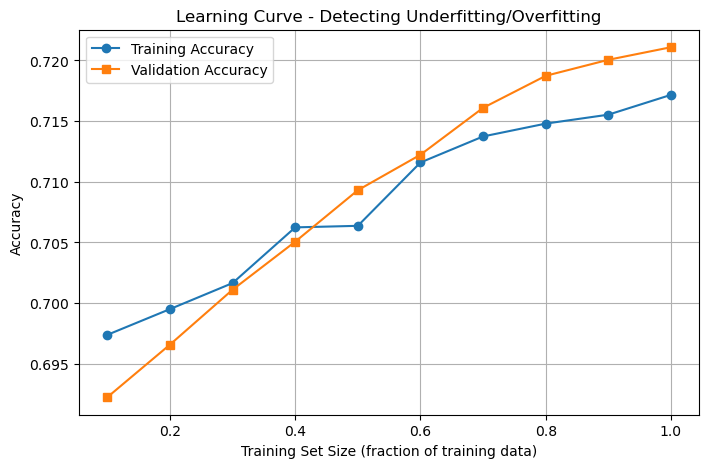

In [172]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

# Visualize underfitting vs overfitting using learning curves
train_sizes = np.linspace(0.1, 1.0, 10)
train_accuracies = []
test_accuracies = []

for train_size in train_sizes:
    # Use increasing portions of training data
    X_part = X_train_vec[:int(train_size * X_train_vec.shape[0])]
    y_part = y_train[:int(train_size * len(y_train))]

    # CORRECT INDENTATION STARTS HERE (4 spaces)
    model_lc = LogisticRegression(max_iter=1000, C=0.01, class_weight='balanced', random_state=42)
    model_lc.fit(X_part, y_part)

    y_train_pred = model_lc.predict(X_part)
    y_test_pred = model_lc.predict(X_test_vec)

    train_accuracies.append(accuracy_score(y_part, y_train_pred))
    test_accuracies.append(accuracy_score(y_test, y_test_pred))
# Plot learning curve
plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_accuracies, label="Training Accuracy", marker='o')
plt.plot(train_sizes, test_accuracies, label="Validation Accuracy", marker='s')
plt.title("Learning Curve - Detecting Underfitting/Overfitting")
plt.xlabel("Training Set Size (fraction of training data)")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()
